<a href="https://colab.research.google.com/github/badaozhiwei-cmyk/Predicting-CO2-Absorption-in-Ionic-Liquid-with-Molecular-Descriptors-and-Explainable-GNN/blob/main/co2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. 克隆整个仓库
!git clone https://github.com/ftyuejian/Predicting-CO2-Absorption-in-Ionic-Liquid-with-Molecular-Descriptors-and-Explainable-GNN.git

# 2. 进入模型所在的子文件夹（这是代码运行的根目录）
%cd Predicting-CO2-Absorption-in-Ionic-Liquid-with-Molecular-Descriptors-and-Explainable-GNN/GNN_for_property_prediction/

# 3. 检查 GPU 是否可用
import torch
if torch.cuda.is_available():
    print(f"✅ GPU 已就绪: {torch.cuda.get_device_name(0)}")
else:
    print("❌ 未检测到 GPU，请按上方说明在‘笔记本设置’中开启 GPU。")

Cloning into 'Predicting-CO2-Absorption-in-Ionic-Liquid-with-Molecular-Descriptors-and-Explainable-GNN'...
remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (27/27), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 115 (delta 20), reused 18 (delta 18), pack-reused 88 (from 2)
Receiving objects: 100% (115/115), 59.83 MiB | 19.94 MiB/s, done.
Resolving deltas: 100% (39/39), done.
Updating files: 100% (41/41), done.
/content/Predicting-CO2-Absorption-in-Ionic-Liquid-with-Molecular-Descriptors-and-Explainable-GNN/GNN_for_property_prediction
✅ GPU 已就绪: Tesla T4


In [2]:
# 1. 检查当前 PyTorch 版本
import torch
print(f"PyTorch Version: {torch.__version__}")

# 2. 安装 PyG 及其依赖
# 注意：PyG 的安装通常比较慢，请耐心等待（约 1-2 分钟）
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-{torch.__version__}.html

# 3. 验证安装是否成功
try:
    import torch_geometric
    print(f"✅ PyTorch Geometric {torch_geometric.__version__} 安装成功！")
except ImportError:
    print("❌ 安装失败，请检查错误信息。")

PyTorch Version: 2.10.0+cu128
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cu128.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 114.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 149.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 127.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 82.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 39.1 MB/s eta 0:00:00
✅ PyTorch Geometric 2.7.0 安装成功！


In [4]:
import os

# 1. 检查 ../clean/ 目录下到底有哪些文件
clean_dir = '../clean/'
if os.path.exists(clean_dir):
    print(f"✅ 目录 {clean_dir} 存在。")
    print(f"包含的文件有: {os.listdir(clean_dir)}")
else:
    print(f"❌ 目录 {clean_dir} 不存在！")

# 2. 检查项目根目录下的 data 文件夹（SMILES 字典所在位置）
data_dir = '../data/'
if os.path.exists(data_dir):
    print(f"✅ 目录 {data_dir} 存在。")
    print(f"包含的文件有: {os.listdir(data_dir)}")

# 3. 尝试列出整个项目结构，确认 data.npy 到底在哪
print("\n--- 查找 data.npy 文件的位置 ---")
!find .. -name "data.npy"

❌ 目录 ../clean/ 不存在！

--- 查找 data.npy 文件的位置 ---
../GNN_for_property_prediction/clean/data.npy


当前工作目录: /content/Predicting-CO2-Absorption-in-Ionic-Liquid-with-Molecular-Descriptors-and-Explainable-GNN/GNN_for_property_prediction
--- 正在初始化数据 ---
----info----
data_length 10116
------------
✅ 数据集加载成功，共有数据: 10116 条
Running on: cuda
--- 开始训练 (预计耗时 1-2 分钟) ---


Train:   0%|          | 0/127 [00:00<?, ?it/s]/content/Predicting-CO2-Absorption-in-Ionic-Liquid-with-Molecular-Descriptors-and-Explainable-GNN/GNN_for_property_prediction/GIN_Runner.py:128: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  loss="{:.04f}".format(float(train_loss/(batch_idx + 1))),


current epoch is more accurate than before and did not overfit the data, so save it
Epoch 1/5: Train loss 0.2271, Validation Loss 0.1439, Learning Rate 0.0010


current epoch is more accurate than before and did not overfit the data, so save it
Epoch 2/5: Train loss 0.1317, Validation Loss 0.1345, Learning Rate 0.0010


current epoch is more accurate than before and did not overfit the data, so save it
Epoch 3/5: Train loss 0.1240, Validation Loss 0.1074, Learning Rate 0.0010


current epoch is more accurate than before and did not overfit the data, so save it
Epoch 4/5: Train loss 0.0960, Validation Loss 0.0653, Learning Rate 0.0010


current epoch is more accurate than before and did not overfit the data, so save it
Epoch 5/5: Train loss 0.0793, Validation Loss 0.0578, Learning Rate 0.0010
--- 正在生成预测图 ---


MAE: 0.058947531994865944 ,R2: 0.8772358414002714 


MAE: 0.05788082799315694 ,R2: 0.8903210569093046 


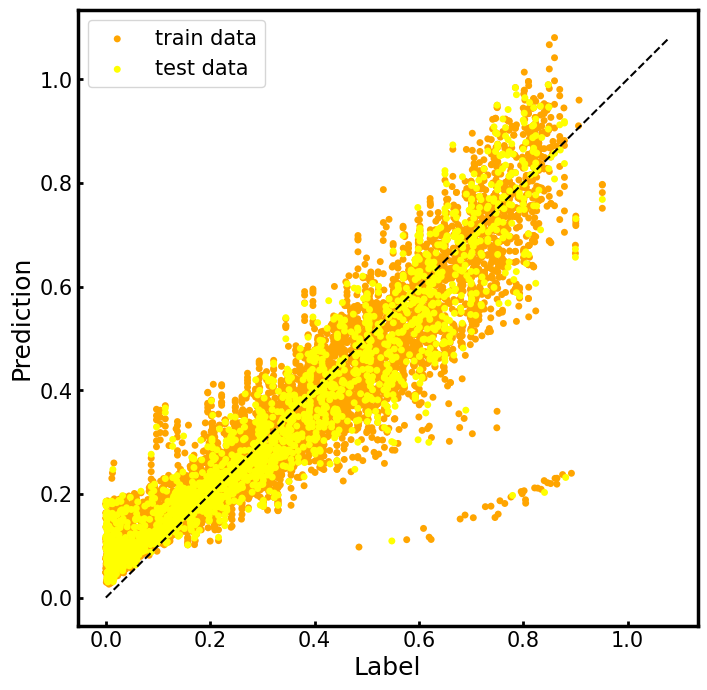

In [5]:
import sys
import os
import torch
from torch_geometric.loader import DataLoader # 确保使用 PyG 的 DataLoader
from torch.utils.data import random_split
import matplotlib.pyplot as plt

# 1. 确保在正确的工作目录
os.chdir('/content/Predicting-CO2-Absorption-in-Ionic-Liquid-with-Molecular-Descriptors-and-Explainable-GNN/GNN_for_property_prediction')
print(f"当前工作目录: {os.getcwd()}")

# 2. 导入模型组件
from GIN_Runner import Args, Runner, IL_set, plot

# 3. 修正 Args 字典中的路径 (根据刚才 find 的结果，它们就在当前目录下)
Args['smiles_dict_path'] = 'data/smiles.csv' # 注意：如果报错，请检查这个文件是否在 clean/ 还是 data/
Args['data_path'] = 'clean/'                 # find 发现 data.npy 在 clean/ 下
Args['load_history_model'] = False           # 设为 False，避免找不到预训练模型报错
Args['epoch'] = 5                            # 先跑 5 轮快速验证流程

print("--- 正在初始化数据 ---")
try:
    # 初始化数据集
    Whole_set = IL_set(path = Args['data_path'])
    Whole_size = len(Whole_set)
    train_size = int(Whole_size * 0.8)
    dev_size = Whole_size - train_size
    train_set, dev_set = random_split(Whole_set, [train_size, dev_size])

    # 使用 PyG 的 DataLoader 处理图数据
    train_loader = DataLoader(train_set, batch_size=Args['batch_size'], shuffle=True, collate_fn=IL_set.collate_fn)
    dev_loader = DataLoader(dev_set, batch_size=Args['batch_size'], shuffle=True, collate_fn=IL_set.collate_fn)
    explain_loader = DataLoader(dev_set, batch_size=Args['batch_size'], shuffle=False, collate_fn=IL_set.collate_fn)

    print(f"✅ 数据集加载成功，共有数据: {Whole_size} 条")

    # 4. 初始化 Runner 并开始训练
    run_G = Runner(Args)
    print("--- 开始训练 (预计耗时 1-2 分钟) ---")
    run_G.train(train_loader, dev_loader, Args)

    # 5. 测试与绘图
    print("--- 正在生成预测图 ---")
    train_pred, train_true = run_G.test(train_loader)
    test_pred, test_true = run_G.test(explain_loader)

    plot(train_true, train_pred, test_true, test_pred, 'GIN_Result.png')
    plt.show()

except Exception as e:
    print(f"❌ 运行出错: {e}")
    # 如果还是找不到文件，列出当前目录下的所有内容帮我诊断
    print("当前目录下的文件清���:", os.listdir('.'))
    if os.path.exists('clean'):
        print("clean 目录下的文件清单:", os.listdir('clean'))

--- GAT 模型初始化 ---
----info----
data_length 10116
------------
Running on: cuda


current epoch is more accurate than before and did not overfit the data, so save it
Epoch 1/10: Train loss 0.2926, Validation Loss 0.1828, Learning Rate 0.0010


current epoch is more accurate than before and did not overfit the data, so save it
Epoch 2/10: Train loss 0.0982, Validation Loss 0.0772, Learning Rate 0.0010


Epoch 3/10: Train loss 0.0880, Validation Loss 0.0849, Learning Rate 0.0010


current epoch is more accurate than before and did not overfit the data, so save it
Epoch 4/10: Train loss 0.0743, Validation Loss 0.0560, Learning Rate 0.0010


...

Epoch 8/10: Train loss 0.0740, Validation Loss 0.0758, Learning Rate 0.0010


current epoch is more accurate than before and did not overfit the data, so save it
Epoch 9/10: Train loss 0.0678, Validation Loss 0.0472, Learning Rate 0.0010


current epoch is more accurate than before and did not overfit the data, so save it
Epoch 10/10: Train loss 0.0689, Validation Loss 0.0411, Learning Rate 0.0010
--- GAT 测试结果 ---


MAE: 0.043135956850227745 ,R2: 0.9227493222204464 


MAE: 0.04111282295216082 ,R2: 0.9295040360613234 


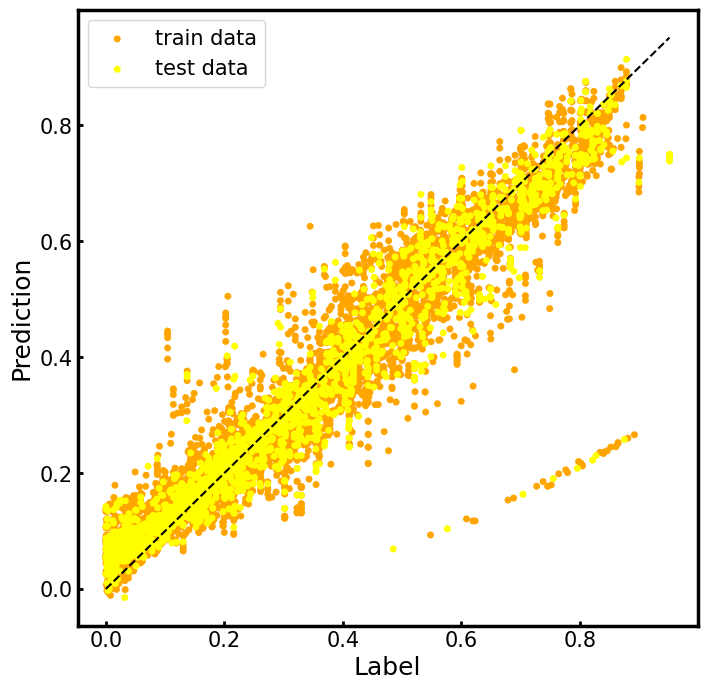

In [6]:
import os
from torch_geometric.loader import DataLoader
from torch.utils.data import random_split
import matplotlib.pyplot as plt

# 确保路径正确
os.chdir('/content/Predicting-CO2-Absorption-in-Ionic-Liquid-with-Molecular-Descriptors-and-Explainable-GNN/GNN_for_property_prediction')

# 从 GAT_Runner 导入
from GAT_Runner import Args as GAT_Args, Runner as GAT_Runner, IL_set, plot

# 修正路径与参数
GAT_Args['smiles_dict_path'] = 'data/smiles.csv'
GAT_Args['data_path'] = 'clean/'
GAT_Args['load_history_model'] = False
GAT_Args['epoch'] = 10  # 设为 10 轮看看效果

print("--- GAT 模型初始化 ---")
Whole_set = IL_set(path = GAT_Args['data_path'])
train_size = int(len(Whole_set) * 0.8)
dev_size = len(Whole_set) - train_size
train_set, dev_set = random_split(Whole_set, [train_size, dev_size])

train_loader = DataLoader(train_set, batch_size=GAT_Args['batch_size'], shuffle=True, collate_fn=IL_set.collate_fn)
dev_loader = DataLoader(dev_set, batch_size=GAT_Args['batch_size'], shuffle=True, collate_fn=IL_set.collate_fn)

# 启动 GAT 训练
run_GAT = GAT_Runner(GAT_Args)
run_GAT.train(train_loader, dev_loader, GAT_Args)

# 测试与绘图
print("--- GAT 测试结果 ---")
tp, tt = run_GAT.test(train_loader)
vp, vt = run_GAT.test(dev_loader)
plot(tt, tp, vt, vp, 'GAT_Result.png')
plt.show()

--- GCN 模型初始化 ---
Running on: cuda


current epoch is more accurate than before and did not overfit the data, so save it
Epoch 1/10: Train loss 0.2081, Validation Loss 0.1059, Learning Rate 0.0010


current epoch is more accurate than before and did not overfit the data, so save it
Epoch 2/10: Train loss 0.1240, Validation Loss 0.0967, Learning Rate 0.0010


current epoch is more accurate than before and did not overfit the data, so save it
Epoch 3/10: Train loss 0.1114, Validation Loss 0.0895, Learning Rate 0.0010


Epoch 4/10: Train loss 0.1056, Validation Loss 0.1163, Learning Rate 0.0010


...

Epoch 8/10: Train loss 0.1016, Validation Loss 0.1095, Learning Rate 0.0010


Epoch 9/10: Train loss 0.0959, Validation Loss 0.0916, Learning Rate 0.0010


Epoch 10/10: Train loss 0.0963, Validation Loss 0.0864, Learning Rate 0.0010
--- GCN 测试结果 ---


MAE: 0.08682328936982714 ,R2: 0.7384481898883681 


MAE: 0.08647955305831971 ,R2: 0.741857762680239 


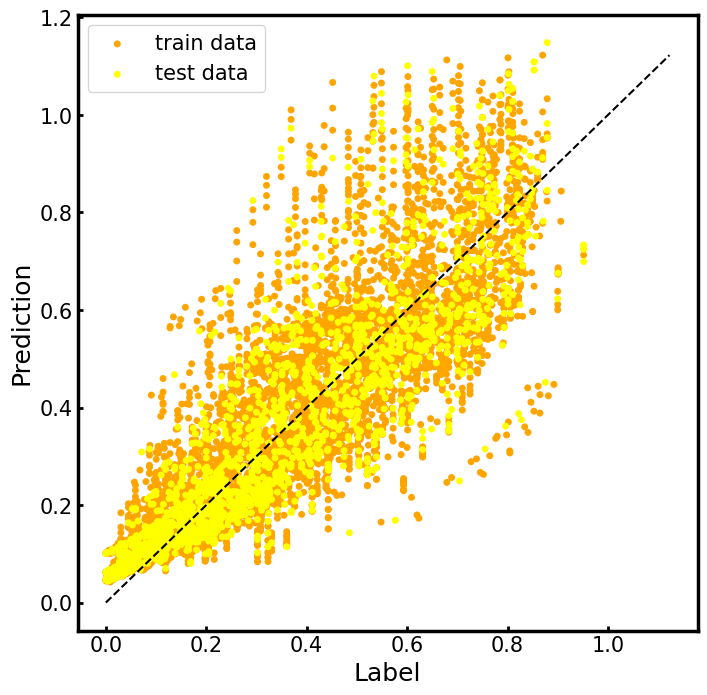

In [7]:
# 从 GCN_Runner 导入
from GCN_Runner import Args as GCN_Args, Runner as GCN_Runner, IL_set, plot

# 修正路径与参数
GCN_Args['smiles_dict_path'] = 'data/smiles.csv'
GCN_Args['data_path'] = 'clean/'
GCN_Args['load_history_model'] = False
GCN_Args['epoch'] = 10

print("--- GCN 模型初始化 ---")
# 数据集已经分好了，直接用上面的 train_set/dev_set 即可，这样对比更公平
train_loader = DataLoader(train_set, batch_size=GCN_Args['batch_size'], shuffle=True, collate_fn=IL_set.collate_fn)
dev_loader = DataLoader(dev_set, batch_size=GCN_Args['batch_size'], shuffle=True, collate_fn=IL_set.collate_fn)

# 启动 GCN 训练
run_GCN = GCN_Runner(GCN_Args)
run_GCN.train(train_loader, dev_loader, GCN_Args)

# 测试与绘图
print("--- GCN 测试结果 ---")
tp, tt = run_GCN.test(train_loader)
vp, vt = run_GCN.test(dev_loader)
plot(tt, tp, vt, vp, 'GCN_Result.png')
plt.show()

In [8]:
# 纯预测代码块
Args['epoch'] = 0
Args['load_history_model'] = True # 加载作者的预训练权重
run_G = Runner(Args)
# 直接跳过 train，执行 test
test_pred, test_true = run_G.test(dev_loader)

Running on: cuda
loading history model..
finish loading


MAE: 0.016680293154972554 ,R2: 0.9582345974390675 


In [13]:
# 运行这段代码来自动修复 Explainer.py 中的 Bug
import os

file_path = '/content/Predicting-CO2-Absorption-in-Ionic-Liquid-with-Molecular-Descriptors-and-Explainable-GNN/Explainer_for_ionic_molecule/Explainer.py'

with open(file_path, 'r') as f:
    content = f.read()

# 替换掉那个报错的旧构造函数
old_code = "hard_edge_mask = torch.BoolTensor([True] * edge_index.size(1), \n                                              device=edge_mask.device)"
new_code = "hard_edge_mask = torch.ones(edge_index.size(1), dtype=torch.bool, device=edge_mask.device)"

# 执行替换（考虑到代码缩进，我们用更精确的字符串匹配）
content = content.replace("torch.BoolTensor([True] * edge_index.size(1),", "torch.ones(edge_index.size(1), dtype=torch.bool,")

with open(file_path, 'w') as f:
    f.write(content)

print("✅ Explainer.py 修复完成！请重新运行解释代码。")

✅ Explainer.py 修复完成！请重新运行解释代码。


--- 正在同步模型至 CPU 环境 ---
--- 正在同步数据至 CPU 环境 ---
--- 正在计算分子贡献度 (GNNExplainer) ---


Explain graph: 100%|██████████| 100/100 [07:27<00:00,  4.47s/it]


--- 正在提取单分子结构并清洗绘图数据 ---
--- 正在生成可视化图像 (仅显示真实化学键) ---


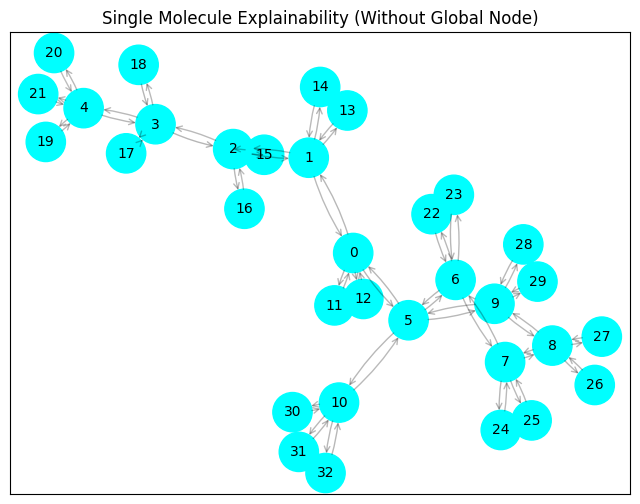

当前分子最关键的化学键局部索引 (前3名): [37, 5, 76]


In [24]:
import os
import sys
import torch
import matplotlib.pyplot as plt

# 1. 确保路径引用正确
sys.path.append('/content/Predicting-CO2-Absorption-in-Ionic-Liquid-with-Molecular-Descriptors-and-Explainable-GNN/Explainer_for_ionic_molecule')
from Explainer import IL_Explainer

# 2. 获取模型并强制移动到 CPU
print("--- 正在同步模型至 CPU 环境 ---")
model_cpu = run_G.get_model().to('cpu')

# 初始化解释器，绑定 CPU 模型
explainer = IL_Explainer(model=model_cpu, epochs=100, return_type='raw', log=True)

# 3. 获取并准备数据 (强制在 CPU 上计算)
print("--- 正在同步数据至 CPU 环境 ---")
batch_data = next(iter(explain_loader))
graph, cond, label = batch_data

# 强制将输入数据停留在 CPU，不要使用 run_G._device
graph = graph.to('cpu')
cond = cond.to('cpu')

# 4. 执行解释算法 (计算整个 Batch 的贡献度)
print("--- 正在计算分子贡献度 (GNNExplainer) ---")
node_mask, edge_mask = explainer.explain_graph(graph, cond)

# 5. 【关键修复】过滤出单个真实分子，并物理剔除虚拟全局节点
print("--- 正在提取单分子结构并清洗绘图数据 ---")
edge_index_cpu = graph.edge_index.cpu()
edge_mask_cpu = edge_mask.cpu()
batch_cpu = graph.batch.cpu()

# a. 定位第一个分子（Batch 0）的所有节点索引
nodes_in_mol_0 = (batch_cpu == 0).nonzero(as_tuple=True)[0]

# b. 剔除最后一个节点（因为我们明确知道在 Dataset 阶段，全局节点是追加在最后的）
real_atoms_mol_0 = nodes_in_mol_0[:-1]

# c. 创建掩码：只保留连线两端都属于真实原子的边（化学键）
mask_src = torch.isin(edge_index_cpu[0], real_atoms_mol_0)
mask_dst = torch.isin(edge_index_cpu[1], real_atoms_mol_0)
edge_filter_mask = mask_src & mask_dst

# d. 得到纯净的单分子连边和对应的权重
clean_edge_index = edge_index_cpu[:, edge_filter_mask]
clean_edge_mask = edge_mask_cpu[edge_filter_mask]

# 6. 生成解释图
print("--- 正在生成可视化图像 (仅显示真实化学键) ---")
try:
    plt.figure(figsize=(8, 6))
    explainer.to('cpu')

    # 将清洗后的纯净化学图喂给绘图工具
    ax, G = explainer.visualize_subgraph(
        node_idx=0, # 【修改】因为 -1(全局节点)已被剔除，我们将视角中心改为分子的第0号真实原子
        edge_index=clean_edge_index,
        edge_mask=clean_edge_mask
    )

    plt.title("Single Molecule Explainability (Without Global Node)")
    plt.show()
except Exception as e:
    print(f"❌ 绘图依然报错: {e}")

# 7. 打印该分子的关键化学键索引
print(f"当前分子最关键的化学键局部索引 (前3名): {torch.argsort(clean_edge_mask, descending=True)[:3].tolist()}")

----info----
data_length 10116
------------
--- 正在分析第 10 号分子 (正在训练解释器，请稍候...) ---


Explain graph: 100%|██████████| 150/150 [00:09<00:00, 16.18it/s]


--- 正在���成可视化图像 ---


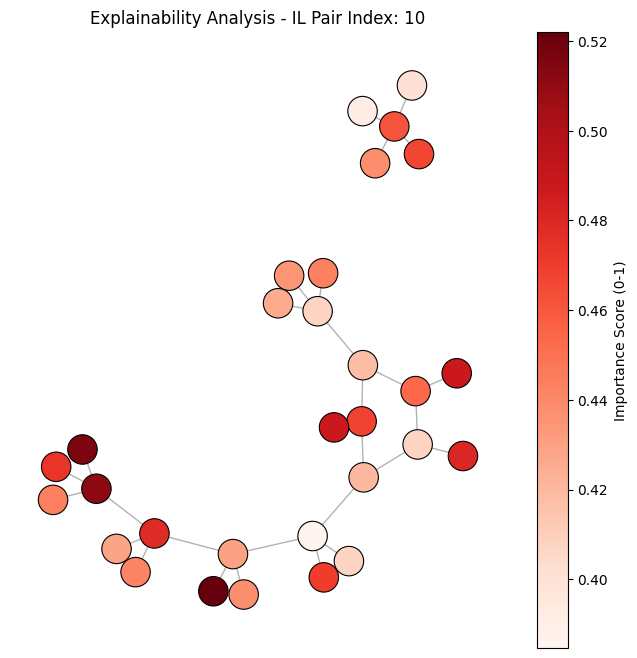

✅ 成功！图中的深红色节点代表对 CO2 吸收预测贡献最大的核心原子。


In [22]:
import os
import sys
import torch
import networkx as nx
import numpy as np
from matplotlib import pyplot as plt

# 1. 环境与路径配置
os.chdir('/content/Predicting-CO2-Absorption-in-Ionic-Liquid-with-Molecular-Descriptors-and-Explainable-GNN/GNN_for_property_prediction')
sys.path.append('/content/Predicting-CO2-Absorption-in-Ionic-Liquid-with-Molecular-Descriptors-and-Explainable-GNN/Explainer_for_ionic_molecule')

from GIN_Runner import Args, Runner
from Explainer import IL_Explainer
from Dataset_explain import IL_set

# 2. 准备模型 (全 CPU 模式最稳)
trained_model = run_G.get_model().to('cpu')
trained_model.eval()

# 3. 加载解释数据集
Args['data_path'] = 'clean/'
Whole_set_explain = IL_set(path=Args['data_path'])
idx = 10
graph, cond, label, num_bond = Whole_set_explain[idx]

# --- 【关键修复 A：补全 Graph 属性】 ---
if graph.edge_attr is None:
    graph.edge_attr = torch.ones((graph.edge_index.size(1), 1))
graph.batch = torch.zeros(graph.x.size(0), dtype=torch.long)

# --- 【关键修复 B：对齐 cond 维度】 ---
# 模型在 Model.py 第 286 行执行 torch.cat，要求 cond 必须是 2 维的 [1, Features]
if cond.dim() == 1:
    cond = cond.unsqueeze(0) # 将 [Features] 变为 [1, Features]
# -----------------------------------

# 4. 初始化解释器
explainer = IL_Explainer(trained_model, epochs=150, lr=0.001, return_type='raw', log=True)
explainer.to('cpu')

# 5. 执行解释 (CPU 计算)
graph = graph.to('cpu')
cond = cond.to('cpu')

print(f"--- 正在分析第 {idx} 号分子 (正在训练解释器，请稍候...) ---")
try:
    # node_feat_mask: 哪些原子特征重要 | edge_mask: 哪些化学键重要
    node_feat_mask, edge_mask = explainer.explain_graph(graph, cond)
except Exception as e:
    print(f"❌ 解释器内部运行报错: {e}")
    print("提示：这通常是由于 Model.py 内部拼接操作对输入形状要求极严导致的。")
    raise e

# 6. 后处理：计算原子贡献分
edge_mask_np = edge_mask.detach().numpy()
num_node = graph.x.shape[0] - 1
node_mask = edge_mask_np[num_bond:]
w_n = []
for i in range(num_node):
    # 根据作者逻辑：平均正反向边的 Mask 值
    w = (node_mask[i] + node_mask[i + num_node]) / 2
    w_n.append(w)

# 7. 绘图展示
print("--- 正在���成可视化图像 ---")
g = nx.Graph()
g.add_nodes_from(list(range(num_node)))
node_a = graph.edge_index[0][0:num_bond].tolist()
node_b = graph.edge_index[1][0:num_bond].tolist()
g.add_edges_from(list(zip(node_a, node_b)))

plt.figure(figsize=(8, 8))
pos = nx.spring_layout(g, seed=400)
nx.draw_networkx_edges(g, pos, alpha=0.3)
nodes = nx.draw_networkx_nodes(
    g, pos,
    node_size=450,
    node_color=w_n,
    cmap=plt.cm.Reds,
    edgecolors='black',
    linewidths=0.8
)

plt.colorbar(nodes, label='Importance Score (0-1)')
plt.title(f"Explainability Analysis - IL Pair Index: {idx}")
plt.axis("off")
plt.show()

print(f"✅ 成功！图中的深红色节点代表对 CO2 吸收预测贡献最大的核心原子。")